In [2]:
import pandas as pd

data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/TrafficRisk_Classifier/TrafficRisk_Classifier.csv")
data.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal


Select important features

In [3]:
features = [
    "duration","src_bytes","dst_bytes",
    "count","same_srv_rate","diff_srv_rate"
]

X = data[features]
y = data["label"]

In [4]:
print(X)

        duration  src_bytes  dst_bytes  count  same_srv_rate  diff_srv_rate
0              0        491          0      2           1.00           0.00
1              0        146          0     13           0.08           0.15
2              0          0          0    123           0.05           0.07
3              0        232       8153      5           1.00           0.00
4              0        199        420     30           1.00           0.00
...          ...        ...        ...    ...            ...            ...
125968         0          0          0    184           0.14           0.06
125969         8        105        145      2           1.00           0.00
125970         0       2231        384      1           1.00           0.00
125971         0          0          0    144           0.06           0.05
125972         0        151          0      1           1.00           0.00

[125973 rows x 6 columns]


Convert labels

In [5]:
def simplify_label(label):
    if label == "normal":
        return 0   # Safe
    elif label in ["ipsweep","nmap","portsweep","satan"]:
        return 1   # Suspicious
    else:
        return 2   # Dangerous

y = y.apply(simplify_label)

In [6]:
print(y)

0         0
1         0
2         2
3         0
4         0
         ..
125968    2
125969    0
125970    0
125971    2
125972    0
Name: label, Length: 125973, dtype: int64


Normalize data

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled)

[[-0.11024922 -0.0076786  -0.00491864 -0.71704549  0.77128311 -0.34968303]
 [-0.11024922 -0.00773737 -0.00491864 -0.62098246 -1.32142801  0.48220055]
 [-0.11024922 -0.00776224 -0.00491864  0.33964783 -1.38966859  0.03852931]
 ...
 [-0.11024922 -0.00738219 -0.00482315 -0.72577849  0.77128311 -0.34968303]
 [-0.11024922 -0.00776224 -0.00491864  0.52304088 -1.36692173 -0.0723885 ]
 [-0.11024922 -0.00773652 -0.00491864 -0.72577849  0.77128311 -0.34968303]]


Train-Test Split

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

Train Naive Bayes

In [9]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train, y_train)


GaussianNB()

In [10]:
nb_acc = nb.score(X_test, y_test)
print("Naive Bayes Accuracy:", nb_acc)

Naive Bayes Accuracy: 0.8492558047231593


Evaluation

In [11]:
from sklearn.metrics import confusion_matrix

print("NB Confusion Matrix:")
print(confusion_matrix(y_test, nb.predict(X_test)))


NB Confusion Matrix:
[[12124   551   747]
 [ 1388   794   175]
 [  865    72  8479]]


Confusion Matrix Graph

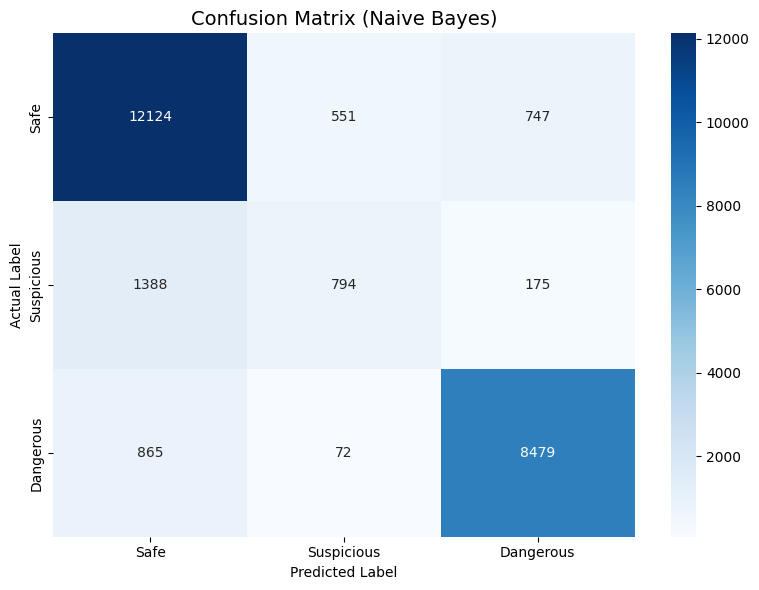

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Predict
y_pred = nb.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Class labels (your 3 classes)
labels = ["Safe", "Suspicious", "Dangerous"]

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)

plt.title('Confusion Matrix (Naive Bayes)', fontsize=14)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')

plt.tight_layout()
plt.show()

Accuracy vs Train Size Graph

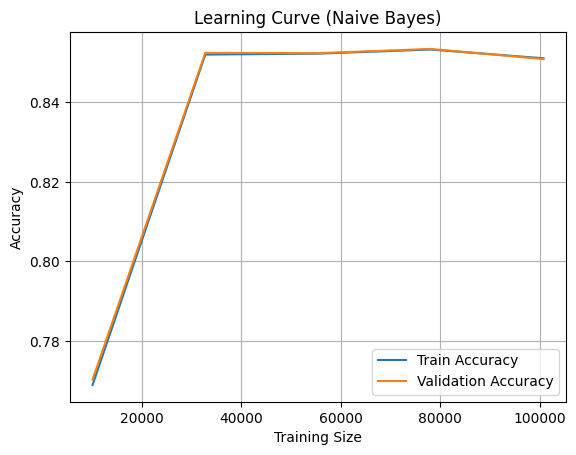

In [13]:
from sklearn.model_selection import learning_curve
import numpy as np

train_sizes, train_scores, test_scores = learning_curve(
    nb, X_scaled, y,
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 5)
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure()
plt.plot(train_sizes, train_mean, label="Train Accuracy")
plt.plot(train_sizes, test_mean, label="Validation Accuracy")

plt.title("Learning Curve (Naive Bayes)")
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

Check the actual output

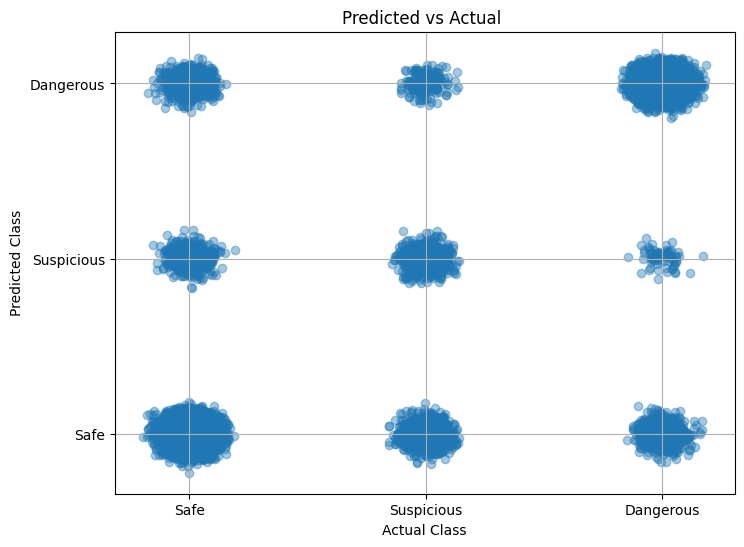

In [20]:
import numpy as np

plt.figure(figsize=(8,6))

plt.scatter(
    y_test + np.random.normal(0, 0.05, len(y_test)),
    y_pred + np.random.normal(0, 0.05, len(y_pred)),
    alpha=0.4
)

plt.xlabel("Actual Class")
plt.ylabel("Predicted Class")
plt.title("Predicted vs Actual ")

plt.xticks([0,1,2], ["Safe","Suspicious","Dangerous"])
plt.yticks([0,1,2], ["Safe","Suspicious","Dangerous"])

plt.grid()
plt.show()

In [14]:
d = float(input("Duration: "))
sb = float(input("Src bytes: "))
db = float(input("Dst bytes: "))1
c = float(input("Count: "))
ssr = float(input("Same srv rate: "))
dsr = float(input("Diff srv rate: "))

new_data = [[d, sb, db, c, ssr, dsr]]
new_data_scaled = scaler.transform(new_data)

pred = nb.predict(new_data_scaled)[0]

print("Result:", ["Safe","Suspicious","Dangerous"][pred])

Duration: 1
Src bytes: 1
Dst bytes: 1
Count: 1
Same srv rate: 1
Diff srv rate: 1
Result: Suspicious


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
